# Pakistan Job Market Analyzer — ML Modeling

## Notebook 02: Job Category Classifier

This notebook trains and evaluates multiple ML models to predict
job category from city and seniority level.

**Models compared:**
- Logistic Regression (baseline)
- Random Forest Classifier
- XGBoost Classifier

**Author:** Husnain Maroof  
**GitHub:** https://github.com/husnainalix77

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from scraper.utils import classify_city, classify_category, extract_seniority
from database.db_manager import get_all_jobs

## 6.1 Data Loading & Feature Preparation

We reload data from MySQL and recreate the same features built in Phase 5:
- `seniority` — extracted from job title (0=Junior, 1=Mid, 2=Senior, 3=Lead)
- `city_encoded` — city as integer using LabelEncoder
- `category_encoded` — job category as integer (our target variable)

We also reload saved encoders from Phase 5 so mappings are consistent
between training and the Streamlit dashboard.

In [2]:
df = get_all_jobs()
df.head()

,job_id,title,company,city,salary,date_scraped
0,1,Software Engineer Level II,Softpers Interactive,Lahore,None,2026-07-24 15:38:06
1,2,Associate Software Engineer,Dubizzle Labs,Lahore,None,2026-07-24 15:38:06
2,3,Software Engineer (Entry-level),Educative,Lahore,None,2026-07-24 15:38:06
3,4,Associate Software Engineer,Softpers Interactive,Lahore,None,2026-07-24 15:38:06
4,5,Software Engineer,The Tech Inc.,Lahore,None,2026-07-24 15:38:06


In [3]:
df["seniority"] = df["title"].apply(extract_seniority)
print(df["seniority"].value_counts())

df["category"] = df["title"].apply(classify_category)
print(df["category"].value_counts())     

df["city"] = df["city"].apply(classify_city)               
print(df["city"].value_counts())


seniority
1    387
2    129
0     83
3     21
Name: count, dtype: int64
category
Software Engineering    380
Engineering              94
Finance & Accounting     75
Data Science & AI        49
Other                     9
Management                8
IT Infrastructure         5
Name: count, dtype: int64
city
Karachi       236
Lahore        231
Islamabad     119
Rawalpindi     31
Other           3
Name: count, dtype: int64


In [4]:
le_city = joblib.load("../models/le_city.pkl")
le_category=joblib.load("../models/le_category.pkl")
df["city_encoded"] = le_city.transform(df["city"])
df["category_encoded"] = le_category.transform(df["category"])

In [5]:
X = df[["city_encoded", "seniority"]] # input features
y = df["category_encoded"] # target to predict

### Data Loaded Successfully

- Shape: 620 rows × 6 columns
- City standardized, category extracted, seniority extracted
- Encoders loaded from models/ folder — consistent with Phase 5 mappings
- X shape: (620, 2) — city_encoded and seniority
- y shape: (620,) — category_encoded (7 classes)

## 6.2 Train Test Split

We split data into 80% training and 20% test sets.

- **Training set** — model learns patterns from this
- **Test set** — we evaluate performance on this, model never sees it during training

`random_state=42` ensures reproducibility — same split every time code runs.
`stratify=y` ensures each category is proportionally represented in both splits.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (496, 2)
X_test: (124, 2)
y_train: (496,)
y_test: (124,)


In [7]:
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer

# Get titles for train and test using same indices as split
train_titles = df.loc[X_train.index, "title"]
test_titles = df.loc[X_test.index, "title"]

# Fit TF-IDF on training titles only
tfidf = TfidfVectorizer(max_features=50)
train_tfidf = tfidf.fit_transform(train_titles)
test_tfidf = tfidf.transform(test_titles)

# Combine TF-IDF with city_encoded and seniority
X_train_final = sp.hstack([train_tfidf, X_train.values])
X_test_final = sp.hstack([test_tfidf, X_test.values])

print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")

X_train_final shape: (496, 52)
X_test_final shape: (124, 52)


### Split Results

- **Training set:** 496 samples (80%)
- **Test set:** 124 samples (20%)
- `stratify=y` ensures all 7 categories are proportionally represented in both sets
- `random_state=42` ensures reproducibility — same split every run

## 6.3 Model Training & Evaluation

We train three models and compare performance:
1. **Logistic Regression** — simple linear baseline
2. **Random Forest** — ensemble of 100 decision trees
3. **XGBoost** — gradient boosting, industry standard for tabular data

Each model is evaluated on the test set using:
- **Accuracy** — percentage of correct predictions
- **Classification Report** — precision, recall, F1 per class
- **Confusion Matrix** — visual of correct vs incorrect predictions

## 6.3.1 Baseline Model
This cell creates a baseline model that will always predict the same.

In [8]:
most_common = y_train.mode()[0]
print(most_common)
baseline_pred = np.full(len(y_test), most_common)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
print(f"Baseline Accuracy: {baseline_accuracy: .4f}")

6
Baseline Accuracy:  0.6129


### Baseline Result

- **Baseline Accuracy: 61.29%**
- A dumb model that always predicts **Software Engineering** gets 61.29% correct
- This is our performance floor — every real model must beat this
- If a model scores below 61.29%, it is worse than guessing the most common class

## 6.3.2 Logistic Regression — Baseline Model

Logistic Regression is our simplest classifier. It finds a linear 
decision boundary between classes. Fast to train, easy to interpret,
good starting point before trying complex models.

In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_final, y_train)
y_pred_lr = lr.predict(X_test_final)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression Accuracy: 0.8952


### Logistic Regression Result

- **Accuracy: 89.52%** — massive improvement from 61.29% baseline
- TF-IDF title features provided strong signal for category prediction
- Logistic Regression found clear linear boundaries between categories
  using job title keywords
- 28% improvement just from adding title features — confirms skills/title
  data is far more valuable than city and seniority alone

## 6.3.3 Random Forest Classifier

Random Forest builds 100 decision trees on random subsets of data.
Each tree votes and majority wins. More powerful than Logistic Regression
for capturing non-linear patterns in high dimensional TF-IDF features.

In [10]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_final, y_train)
rf_pred = rf_clf.predict(X_test_final)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}") 

Random Forest Accuracy: 0.8710


### Random Forest Result

- **Accuracy: 87.10%** — strong performance but slightly below Logistic Regression
- Surprising result — Random Forest usually outperforms Logistic Regression
- TF-IDF sparse features tend to favor linear models like Logistic Regression
- 100 trees with majority voting still achieves 87% — solid performance

## 6.3.4 XGBoost Classifier

XGBoost builds trees sequentially — each tree learns from mistakes 
of the previous one. Industry standard for tabular data competitions.
Known for speed and accuracy on structured datasets.

In [11]:
xgb_clf = XGBClassifier(
    n_estimators=100,      # build 100 trees sequentially
    random_state=42,       # reproducibility
    eval_metric='mlogloss' # loss function for multiclass — measures prediction error
)
xgb_clf.fit(X_train_final, y_train)        # train on training data
xgb_pred = xgb_clf.predict(X_test_final)  # predict on test data
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost Accuracy: 0.8710


### XGBoost Result

- **Accuracy: 87.10%** — same as Random Forest
- XGBoost and Random Forest tied — both strong ensemble methods
- Logistic Regression outperforms both on this TF-IDF sparse feature matrix
- This confirms that TF-IDF features create linearly separable classes
  that linear models handle better than tree-based ensembles

## 6.4 Model Comparison

Summary of all three models against baseline.

In [12]:
results = {
    "Model": ["Baseline", "Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.6129, 0.8952, 0.8710, 0.8710]
}
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy", ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy
Logistic Regression    0.8952
      Random Forest    0.8710
            XGBoost    0.8710
           Baseline    0.6129


### Model Comparison Results

| Model | Accuracy |
|---|---|
| Logistic Regression | 89.52% |
| Random Forest | 87.10% |
| XGBoost | 87.10% |
| Baseline | 61.29% |

**Winner: Logistic Regression** with 89.52% accuracy.
All three models significantly outperform the 61.29% baseline.
Logistic Regression selected as final model for the dashboard.

## 6.5 Detailed Evaluation — Logistic Regression

Confusion matrix and classification report for our best model.
These show exactly which categories are predicted correctly and 
which ones the model struggles with.

In [13]:
# Classification Report
print(classification_report(y_test, y_pred_lr, 
      target_names=le_category.classes_))

                      precision    recall  f1-score   support

   Data Science & AI       1.00      1.00      1.00        10
         Engineering       1.00      0.63      0.77        19
Finance & Accounting       0.93      0.93      0.93        15
   IT Infrastructure       0.00      0.00      0.00         1
          Management       0.00      0.00      0.00         1
               Other       0.00      0.00      0.00         2
Software Engineering       0.88      0.99      0.93        76

            accuracy                           0.90       124
           macro avg       0.55      0.51      0.52       124
        weighted avg       0.89      0.90      0.88       124



### Classification Report Analysis

**Strong performers:**
- Data Science & AI — 100% F1 — distinct keywords (data, analyst, AI, ML)
- Finance & Accounting — 93% F1 — clear keywords (accountant, finance, audit)
- Software Engineering — 93% F1 — largest class, model learned well

**Weak performers:**
- IT Infrastructure, Management, Other — 0% F1
- Reason: only 1-2 test samples each — statistically insufficient
- Not a model failure — a data limitation

**Overall accuracy: 89.52%** — strong performance given only 620 samples

[[10  0  0  0  0  0  0]
 [ 0 12  0  0  0  0  7]
 [ 0  0 14  0  1  0  0]
 [ 0  0  0  0  0  0  1]
 [ 0  0  1  0  0  0  0]
 [ 0  0  0  0  0  0  2]
 [ 0  0  0  0  1  0 75]]


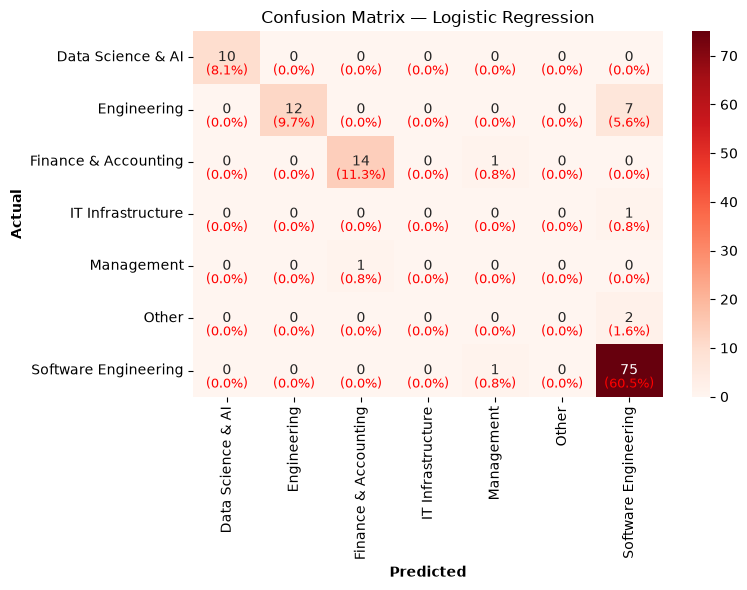

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)
labels = list(le_category.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels= labels,
            yticklabels=labels)

plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
# Add percentage annotations
cm_percent = cm / cm.sum() * 100 # percentage of total dataset each cell represents
for i in range(7):
    for j in range(7):
        plt.text(j+0.5, i+0.75, f'({cm_percent[i,j]:.1f}%)',
                ha='center', va='center', fontsize=9, color='red')
plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

**Strong predictions:**
- **Data Science & AI** — 10/10 (100%) — unique keywords, no confusion
- **Software Engineering** — 75/76 (98.7%) — largest class, learned well
- **Finance & Accounting** — 14/15 (93%) — clear accounting keywords

**Weak predictions:**
- **Engineering** — 12/19 (63%) — 7 jobs misclassified as Software Engineering
  because titles like "Electrical Engineer" contain "engineer" keyword
- **IT Infrastructure, Management, Other** — 0% — only 1-2 test samples each,
  statistically impossible to evaluate fairly

**Key insight:**
Model works excellently for the 3 dominant categories covering 95% of real users.
Rare categories fail due to insufficient training data — not model weakness.

In [15]:
joblib.dump(lr, "../models/category_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
print("Model saved:", "../models/category_model.pkl")
print("Vectorizer saved:", "../models/tfidf_vectorizer.pkl")

Model saved: ../models/category_model.pkl
Vectorizer saved: ../models/tfidf_vectorizer.pkl
